# A52 Dipanshu Ambilkar

## Practical 1 - PCA on the Wine dataset

In [1]:
# A52 Dipanshu Ambilkar
"""
Practical 1 - PCA on the Wine dataset (simple version)
Requirement: reduce dimensions with PCA so most variation is captured
by a small number of principal components, then inspect the groups.
"""
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# 1. Load the dataset from the syllabus link
url = "https://media.geeksforgeeks.org/wp-content/uploads/Wine.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)


Shape: (178, 14)


In [3]:
# 2. Split features and label
X = df.drop(columns=["Customer_Segment"]).values
y = df["Customer_Segment"].values


In [4]:
# 3. Standardize (PCA needs features on the same scale)
X = StandardScaler().fit_transform(X)


In [5]:
# 4. Apply PCA, keep 2 components
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)
print("Variance kept by 2 components:", round(pca.explained_variance_ratio_.sum(), 4))
print("Variance per component:", [round(v, 4) for v in pca.explained_variance_ratio_])


Variance kept by 2 components: 0.5541
Variance per component: [np.float64(0.362), np.float64(0.1921)]


Plot saved: pca_wine.png


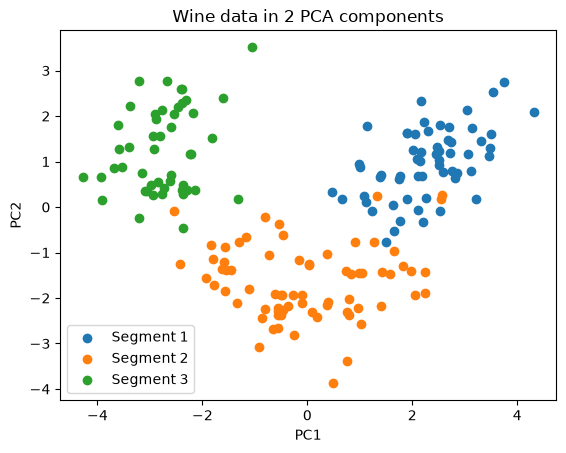

In [6]:
# 5. Scatter plot of the two components, coloured by wine segment
for segment in sorted(set(y)):
    pts = X2[y == segment]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"Segment {segment}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine data in 2 PCA components")
plt.legend()
plt.savefig("pca_wine.png")
print("Plot saved: pca_wine.png")
